## Sentiment Analysis — Exploratory Data Analysis
### Dataset: Yelp Academic Dataset (Review)
### Goal: Load, sample, label, and explore the 3-class sentiment distribution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import os
import json
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# paths
RAW_PATH  = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\data\raw\yelp_academic_dataset_review.json"
PROC_PATH = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\data\processed"
FIGURES   = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\reports\figures"

os.makedirs(PROC_PATH, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nithilan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Load & Sample Dataset
File is 5GB+ — we load line by line and sample 
18,00,000 reviews balanced across 3 classes (600000 each)

In [3]:
def load_yelp(path, samples_per_class=600000):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            record = json.loads(line)
            records.append({
                'text'  : record['text'],
                'stars' : record['stars']
            })
    
    df = pd.DataFrame(records)
    
    # map stars to sentiment
    def map_sentiment(stars):
        if stars <= 2:   return 'Negative'
        elif stars == 3: return 'Neutral'
        else:            return 'Positive'
    
    df['sentiment'] = df['stars'].apply(map_sentiment)
    df['label']     = df['sentiment'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})
    
    # balanced sampling
    df_balanced = (df.groupby('sentiment')
                     .apply(lambda x: x.sample(min(len(x), samples_per_class), random_state=42))
                     .reset_index(drop=True))
    
    return df_balanced

print("Loading dataset... (this may take 1-2 minutes)")
df = load_yelp(RAW_PATH)
print(f"Total samples : {len(df):,}")
print(f"\nClass distribution:\n{df['sentiment'].value_counts()}")
df.head()

Loading dataset... (this may take 1-2 minutes)


C:\Users\Nithilan\AppData\Local\Temp\ipykernel_2080\2271513232.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), samples_per_class), random_state=42))


Total samples : 1,800,000

Class distribution:
sentiment
Negative    600000
Neutral     600000
Positive    600000
Name: count, dtype: int64


,text,stars,sentiment,label
0,Drove one and half hour there. Waited for an h...,1.0,Negative,0
1,So I gave this place a bad review the first ti...,1.0,Negative,0
2,Flowers looked good. They dropped them off hou...,2.0,Negative,0
3,As I sit here I am watching the cook wipe the ...,1.0,Negative,0
4,This is not another Patron review made by many...,1.0,Negative,0


## 2. Basic Info — shape, nulls, duplicates

In [4]:
print(f"Shape       : {df.shape}")
print(f"Null values : {df.isnull().sum().to_dict()}")
print(f"Duplicates  : {df.duplicated(subset='text').sum():,}")
print(f"\nStar distribution:\n{df['stars'].value_counts().sort_index()}")

Shape       : (1800000, 4)
Null values : {'text': 0, 'stars': 0, 'sentiment': 0, 'label': 0}
Duplicates  : 1,600

Star distribution:
stars
1.0    397343
2.0    202657
3.0    600000
4.0    185828
5.0    414172
Name: count, dtype: int64


## 3. Class Distribution

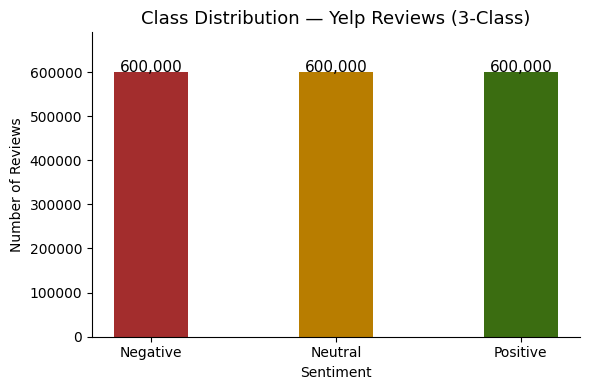

Saved → class_distribution.png


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

colors  = ['#A32D2D', '#B87D00', '#3B6D11']
labels  = ['Negative', 'Neutral', 'Positive']
counts  = [df[df['sentiment'] == l].shape[0] for l in labels]

bars = ax.bar(labels, counts, color=colors, width=0.4)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 300,
            f'{count:,}', ha='center', fontsize=11)

ax.set_title('Class Distribution — Yelp Reviews (3-Class)', fontsize=13)
ax.set_xlabel('Sentiment')
ax.set_ylabel('Number of Reviews')
ax.set_ylim(0, max(counts) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'class_distribution.png'), dpi=150)
plt.show()
print("Saved → class_distribution.png")

## 4. Review Length Distribution

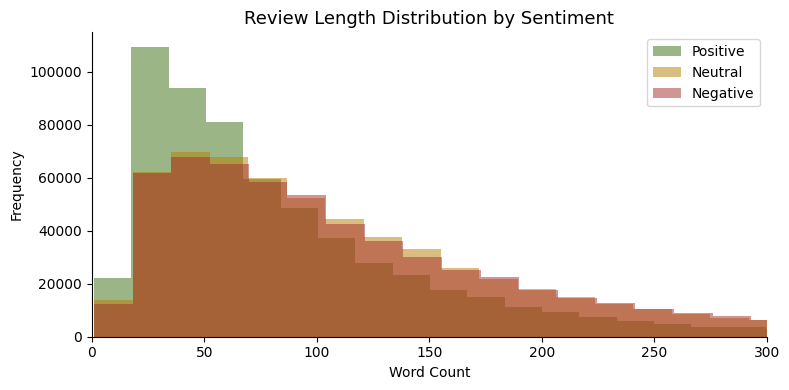

              count    mean     std  min   25%   50%    75%     max
sentiment                                                          
Negative   600000.0  133.91  121.38  1.0  55.0  98.0  170.0  1032.0
Neutral    600000.0  124.26  104.57  1.0  54.0  95.0  161.0  1028.0
Positive   600000.0   91.88   84.43  1.0  37.0  66.0  117.0   996.0


In [6]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(8, 4))

colors = {'Positive': '#3B6D11', 'Neutral': '#B87D00', 'Negative': '#A32D2D'}
for label, color in colors.items():
    subset = df[df['sentiment'] == label]['word_count']
    ax.hist(subset, bins=60, alpha=0.5, label=label, color=color)

ax.set_title('Review Length Distribution by Sentiment', fontsize=13)
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 300)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'length_distribution.png'), dpi=150)
plt.show()

print(df.groupby('sentiment')['word_count'].describe().round(2))

## 5. Most Frequent Words Per Class

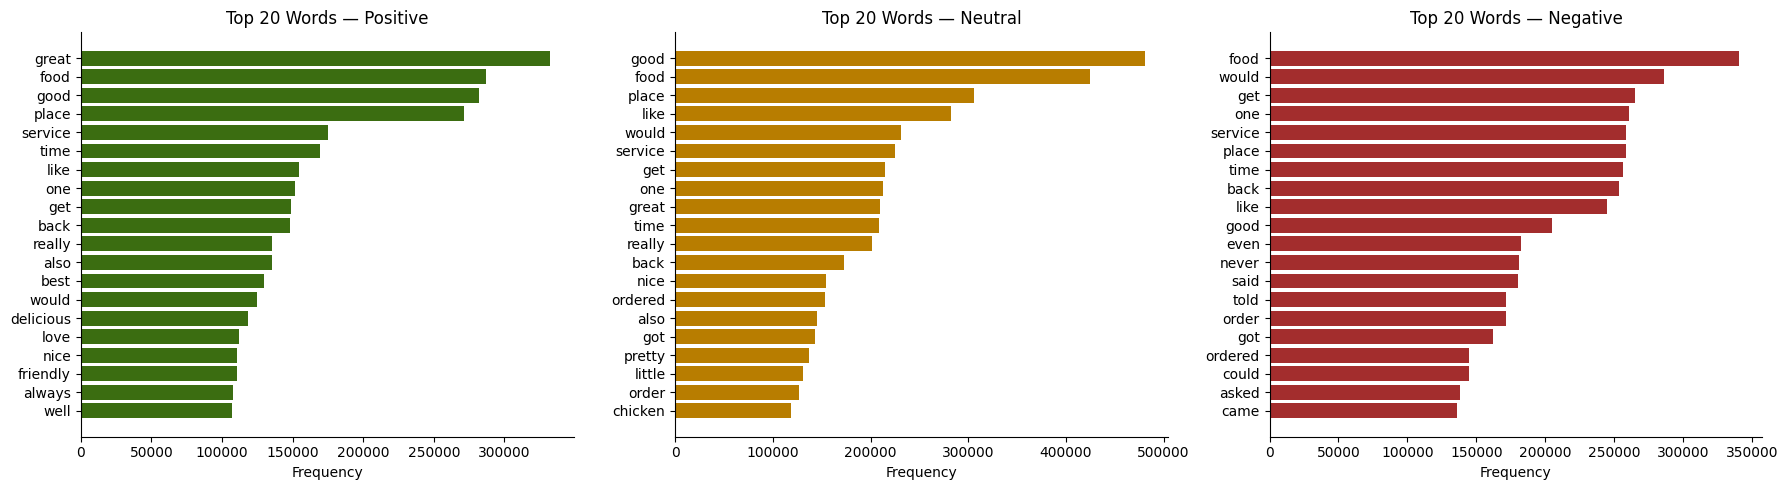

Saved → top_words.png


In [7]:
def get_top_words(df, sentiment, n=20):
    text  = ' '.join(df[df['sentiment'] == sentiment]['text'].tolist()).lower()
    words = re.findall(r'\b[a-z]{3,}\b', text)
    words = [w for w in words if w not in stop_words]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment, color in zip(axes,
    ['Positive', 'Neutral', 'Negative'],
    ['#3B6D11',  '#B87D00', '#A32D2D']):
    
    words    = get_top_words(df, sentiment)
    words_df = pd.DataFrame(words, columns=['word', 'count'])
    ax.barh(words_df['word'][::-1], words_df['count'][::-1], color=color)
    ax.set_title(f'Top 20 Words — {sentiment}', fontsize=12)
    ax.set_xlabel('Frequency')
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'top_words.png'), dpi=150)
plt.show()
print("Saved → top_words.png")

## 6. Word Clouds Per Class

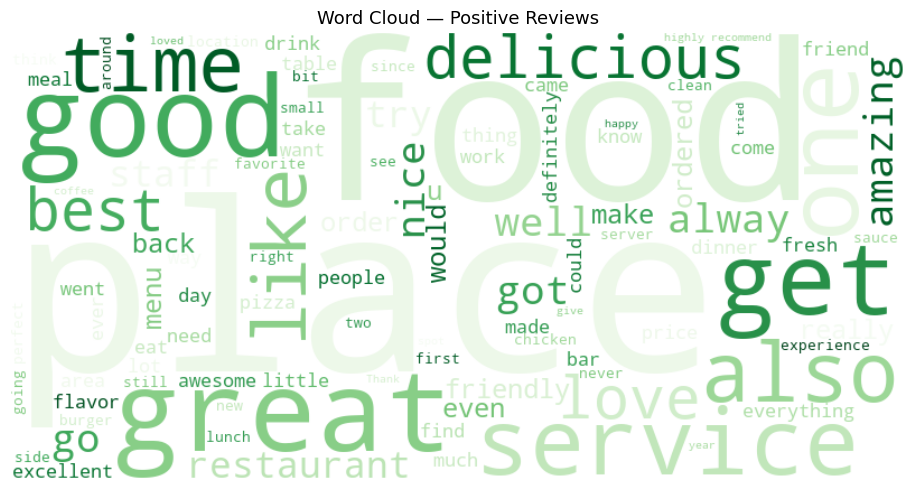

Saved → wordcloud_positive.png


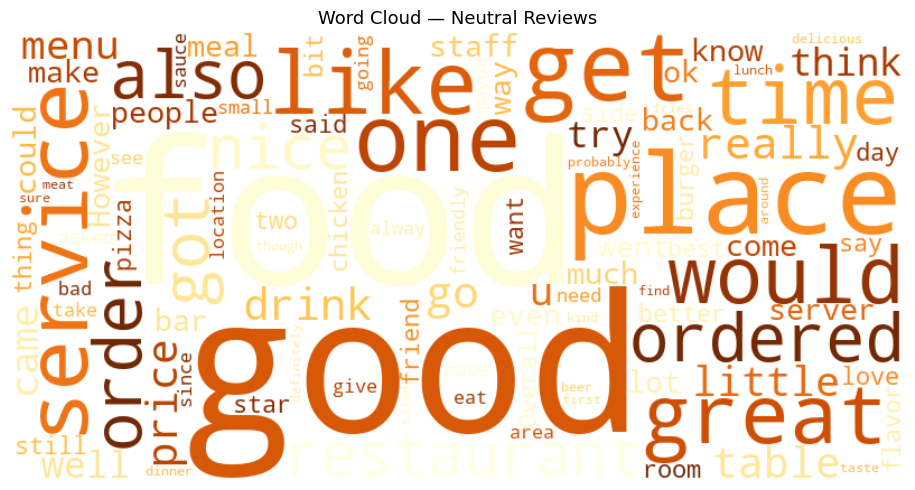

Saved → wordcloud_neutral.png


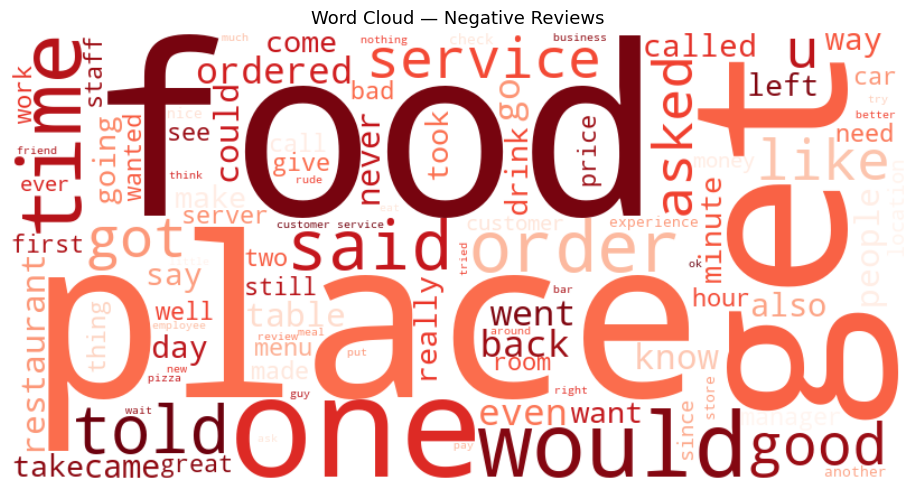

Saved → wordcloud_negative.png


In [8]:
colormaps = {'Positive': 'Greens', 'Neutral': 'YlOrBr', 'Negative': 'Reds'}

for sentiment, cmap in colormaps.items():
    text = ' '.join(
        df[df['sentiment'] == sentiment]['text']
        .sample(min(10000, df[df['sentiment'] == sentiment].shape[0]), random_state=42)
        .tolist()
    )
    
    wc = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap=cmap,
                   stopwords=stop_words,
                   max_words=100).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud — {sentiment} Reviews', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, f'wordcloud_{sentiment.lower()}.png'), dpi=150)
    plt.show()
    print(f"Saved → wordcloud_{sentiment.lower()}.png")

In [9]:
df[['text', 'stars', 'sentiment', 'label']].to_csv(
    os.path.join(PROC_PATH, 'reviews_sampled.csv'), index=False
)
print(f"Saved → data/processed/reviews_sampled.csv")
print(f"Shape : {df.shape}")

Saved → data/processed/reviews_sampled.csv
Shape : (1800000, 5)
